# About

This notebook provides an example of using the COMSOL model generator to solve the scattering of an acoustic plane wave by a sphere.


# Example

The COMSOL model evaluates the extinction power
$$
W_\text{ext} = - \int r^2 d\Omega \frac{1}{2}\text{Re}\left[ p_\text{s}^* (\vec{v}_\text{b}\cdot \vec{n}) + p_\text{b}^* (\vec{v}_\text{s}\cdot \vec{n}) \right]
$$
For a spherical surface of radius $R_\text{int}$:
$$
W_\text{ext} = \frac{1}{2\omega\rho_\text{host}} \int R_\text{int}^2 d\Omega \text{Im}\left[ p_\text{s}^* \left(\frac{\partial p_\text{b}}{\partial \vec{r}}\cdot \vec{r}\right) + p_\text{b}^* \left(\frac{\partial p_\text{s}}{\partial \vec{r}}\cdot \vec{r}\right) \right]
$$

The model also defines variables for calculating the scattering power:
$$
W_\text{sc} = -\frac{1}{2\omega\rho_\text{host}} \int R_\text{int}^2 d\Omega \text{Im}\left[ p_\text{s}^* \left(\frac{\partial p_\text{s}}{\partial \vec{r}}\cdot \vec{r}\right) \right]
$$


The extinction and scattering cross-sections are then obtained as
$$
\sigma_\text{ext} = \frac{W_\text{ext}}{I_0}
$$
$$
\sigma_\text{sc} = \frac{W_\text{sc}}{I_0}
$$
where $I_0 = p_0^2 / (2c_\text{host}\rho_\text{host})$ is the intensity of the incident plane wave.

In [1]:
# In case something goes wrong, you can enable debug logging for the mph package.


# import logging
# import sys

# logging.basicConfig(
#     format="%(asctime)s (%(name)s) [%(levelname)s] %(message)s",
#     handlers=[logging.StreamHandler(sys.stdout)]
# )
# logging.getLogger('mph').setLevel(logging.DEBUG)

In [2]:
import mph
from comsol.sphere_scattering import create_new_model, ModelParameters
import matplotlib.pyplot as plt

Create a COMSOL client.
See the [MPh](https://github.com/MPh-py/MPh) documentation for details on configuring the client for your specific setup.

In [3]:
client = mph.Client(port=2036)

Now we create a new model with specific parameters:

- `a`: sphere radius  
- `c_host`: speed of sound in the host medium  
- `c_sphere`: speed of sound in the sphere  
- `rho_host`: density of the host medium  
- `rho_sphere`: density of the sphere

In [4]:
parameters = ModelParameters(
    a="1[m]",
    c_host="1[m/s]",
    c_sphere="0.3[m/s]",
    rho_host="1[kg/m^3]",
    rho_sphere="1[kg/m^3]",
    freq_start="0.001[Hz]",
    freq_step="0.003[Hz]",
    freq_stop="0.3[Hz]",
)
model = create_new_model(client, parameters)

Solve the model.

In [6]:
model.solve()

Evaluate the frequency, extinction, and scattering cross-sections:

In [7]:
freq = model.evaluate("freq", "Hz")
sigma_ext = model.evaluate("W_ext / I0", "m^2")
sigma_sc = model.evaluate("W_sc / I0", "m^2")

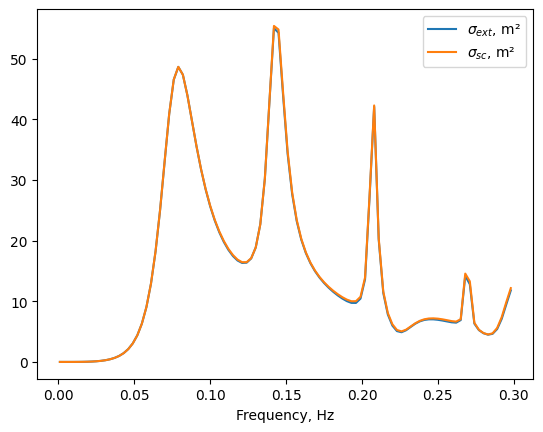

In [8]:
plt.plot(freq, sigma_ext, label="$\\sigma_{ext}$, m²")
plt.plot(freq, sigma_sc, label="$\\sigma_{sc}$, m²")
plt.legend()
plt.xlabel("Frequency, Hz")
plt.show()

Save the model

In [9]:
model.save()

Disconnect the COMSOL client.

In [10]:
client.disconnect()